In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42

if not os.path.exists("heart.csv"):
    raise FileNotFoundError("Put heart.csv in the same folder as this notebook.")       # choose heart.csv when asked

df = pd.read_csv("heart.csv")
print(df.shape)
print(df.isnull().sum())
print(df["HeartDisease"].value_counts())

(918, 12)
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
HeartDisease
1    508
0    410
Name: count, dtype: int64


In [3]:
df_clean = df.copy()

# Zeros in these columns are not realistic, so replace them with the median
for col in ["Cholesterol", "RestingBP"]:
    median_value = df_clean.loc[df_clean[col] > 0, col].median()
    df_clean.loc[df_clean[col] == 0, col] = median_value

X = pd.get_dummies(df_clean.drop(columns="HeartDisease"), dtype=int)
y = df_clean["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)
print(list(X.columns))

(734, 20) (184, 20)
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


In [4]:
k_values = range(1, 26)
cv_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k),
                             X_train_scaled, y_train, cv=5).mean()
             for k in k_values]
best_k = list(k_values)[int(np.argmax(cv_scores))]
print("Best k:", best_k, "| cross-validation accuracy:", round(max(cv_scores), 3))

models = {
    f"KNN (k={best_k})": KNeighborsClassifier(n_neighbors=best_k),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"{name:22s} test accuracy: {acc:.3f}")

Best k: 15 | cross-validation accuracy: 0.854
KNN (k=15)             test accuracy: 0.880
Logistic Regression    test accuracy: 0.891
Random Forest          test accuracy: 0.880


Test accuracy: 0.88
              precision    recall  f1-score   support

  No disease       0.88      0.84      0.86        82
     Disease       0.88      0.91      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



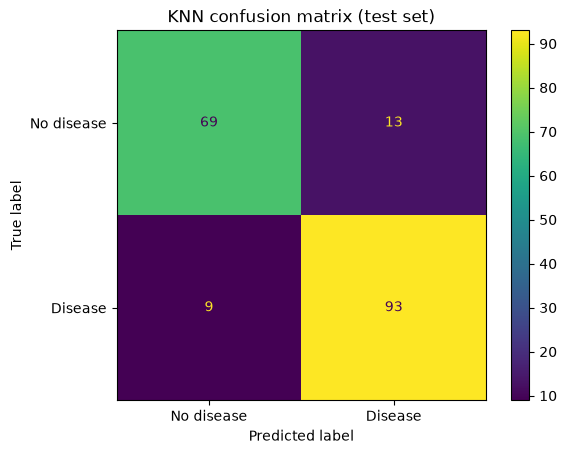

In [5]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred, target_names=["No disease", "Disease"]))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No disease", "Disease"])
plt.title("KNN confusion matrix (test set)")
plt.show()

In [6]:
joblib.dump(knn_model, "KNN_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "columns.pkl")

example = {"Age": 55, "RestingBP": 140, "Cholesterol": 250, "FastingBS": 1,
           "MaxHR": 120, "Oldpeak": 2.0, "Sex_M": 1, "ChestPainType_ASY": 1,
           "RestingECG_Normal": 1, "ExerciseAngina_Y": 1, "ST_Slope_Flat": 1}
row = pd.DataFrame([example])
cols = joblib.load("columns.pkl")
for c in cols:
    if c not in row.columns:
        row[c] = 0
row = row[cols]
print("High risk" if knn_model.predict(scaler.transform(row))[0] == 1 else "Low risk")

High risk
